In [2]:
import astropy as ap
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy import units as u
from astropy import constants as apc
from IPython import display
from time import time
from tqdm import trange

os.environ['CUPY_DUMP_CUDA_SOURCE_ON_ERROR'] = '1'

In [3]:
G = apc.G.to(u.kpc**3 / u.yr**2 / u.solMass)
G_flt = float(G * u.yr**2 * u.solMass / u.kpc**3)
dt = 1e-3

time_derivative = cp.RawKernel(r'''
extern "C" __global__
void time_derivative(const double q[6], double q_dot[6]) {
    double G = %s;
    double solar_mass = 1.;
    
    double r = sqrt(q[0]*q[0] + q[1]*q[1] + q[2]*q[2]);
    for (int j = 0; j < 3; j++) {
        q_dot[j] = q[j+3];
        q_dot[j+3] = -G * solar_mass * q[j] / (r*r*r);
    }
}
''' % (G_flt,), 'time_derivative')


def time_step(q):
    # first iteration prediction
    q_dot1 = cp.zeros_like(q)
    time_derivative((1,), (1,), (q, q_dot1))
    q_tmp = q + dt * q_dot1
    
    # second iteration
    q_dot2 = cp.zeros_like(q)
    time_derivative((1,), (1,), (q_tmp, q_dot2))
    
    return q + dt/2 * (q_dot1 + q_dot2)


def print_time(start_time, loop_i, loop_length):
    progress = loop_i/loop_length
    est_time = (1/progress - 1) * (time() - start_time)
    print(f'Progress: {100*progress:.0f}%\t Estimated time left: {est_time:.0f}s', end='\t ')
    print('|'*int(progress*50 - 1) + '\\' + '_'*int(50 - progress*50))

In [4]:
# initial conditions: Earth at perihelion (y=0, v_x=0)
perihelion = float((147_105_052 * u.km).to(u.kpc) / u.kpc)
orbital_velocity = float((30.29 * u.km / u.s).to(u.kpc / u.yr) * u.yr / u.kpc)
m_earth = float(apc.M_earth.to(u.solMass) / u.solMass)

q_init = cp.array([ perihelion, 0., 0., 0., orbital_velocity, 0. ])

T = 5e3
N_pts = int(T/dt)
ts = np.arange(0, T, dt)
qs = cp.zeros((N_pts+1, 6))
qs[0] = q_init
q = q_init

start_time = time()
for i in trange(N_pts, miniters=10000):
    q = time_step(q)
    qs[i+1] = q[:]
    
#     if i % 10000 == 1:
#         print_time(start_time, i, N_pts)
        
print(f'Total time: {time() - start_time:.0f}s')
qs = cp.asnumpy(qs)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000000/5000000 [09:34<00:00, 8707.81it/s]


Total time: 574s


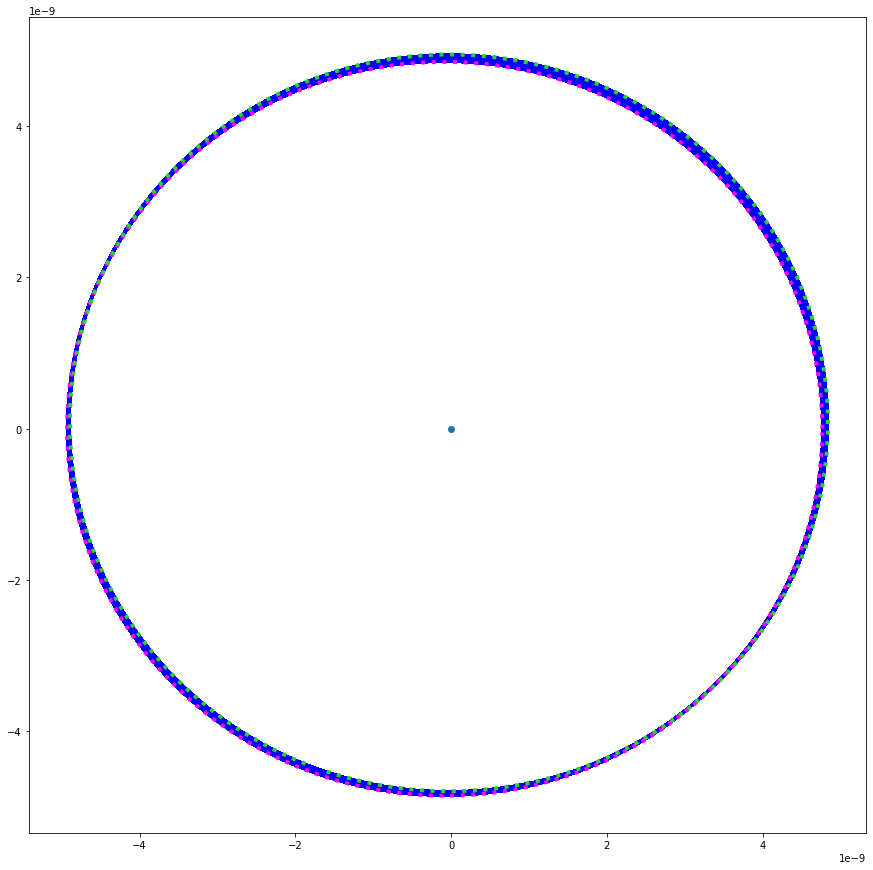

In [5]:
plt.figure(figsize=(15, 15))
plt.plot(qs[:, 0], qs[:, 1], 'b--')
plt.plot(qs[:1000, 0], qs[:1000, 1], ':', c='magenta', lw=4)
plt.plot(qs[-1000:, 0], qs[-1000:, 1], ':', c='limegreen', lw=4)
plt.scatter(0, 0)

In [6]:
qs = cp.asnumpy(qs)
Es = (qs[:, 3]**2 + qs[:, 4]**2 + qs[:, 5]**2)/2 - G_flt / np.sqrt(qs[:, 0]**2 + qs[:, 1]**2 + qs[:, 2]**2)

avg = sum(Es)/N_pts
max_deviation = max(max(Es) - avg, avg - min(Es))/(-avg)
print(f'Maximum energy deviation of the system: {max_deviation*100:.2f}%')

Maximum energy deviation of the system: 0.19%


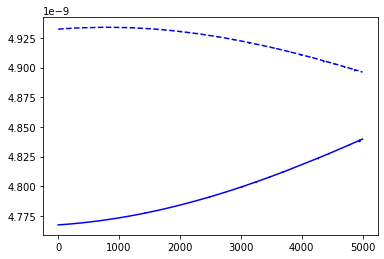

In [7]:
plt.plot(np.array([ max(qs[i:i+1000, 0]) for i in range(0, N_pts, 1000) ]), 'b')
plt.plot(np.array([ -min(qs[i:i+1000, 0]) for i in range(0, N_pts, 1000) ]), 'b--')
# the minimum and maximum x-value for each orbit

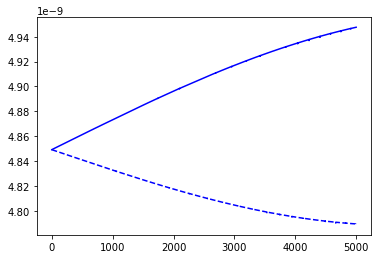

In [8]:
plt.plot(np.array([ max(qs[i:i+1000, 1]) for i in range(0, N_pts, 1000) ]), 'b')
plt.plot(np.array([ -min(qs[i:i+1000, 1]) for i in range(0, N_pts, 1000) ]), 'b--')
# the minimum and maximum y-value for each orbit

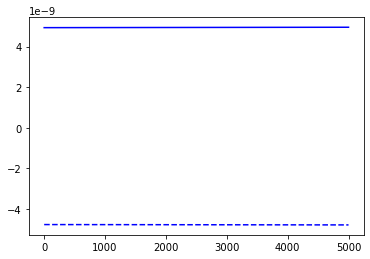

In [18]:
plt.plot([ max(np.sqrt(qs[i:i+1000, 0]**2 + qs[i:i+1000, 1]**2)) for i in range(0, N_pts, 1000) ], 'b')
plt.plot([ -min(np.sqrt(qs[i:i+1000, 0]**2 + qs[i:i+1000, 1]**2)) for i in range(0, N_pts, 1000) ], 'b--')
# the perihelion and aphelion of each orbit - constant -> precession?